## Using a dataset with significant overlap (noise), train multiple SVMs with 𝐶 values of 0.01, 1, and 100.
* ## Task: Observe the margin width and the number of misclassified points in the training set for each. Describe the relationship between the regularization parameter 𝐶 and the model's tolerance for errors.

In [2]:
from sklearn.datasets import make_classification
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import numpy as np

# Create overlapping dataset
X, y = make_classification(
    n_samples=200,
    n_features=2,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=0.8,
    flip_y=0.2,   # add noise
    random_state=42
)


In [4]:
C_values = [0.01, 1, 100]

models = []

for C in C_values:
    svm = SVC(kernel="linear", C=C)
    svm.fit(X, y)
    models.append(svm)


In [6]:
def plot_svm(model, title):
    plt.scatter(X[:,0], X[:,1], c=y, cmap="coolwarm")

    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    xx = np.linspace(xlim[0], xlim[1], 30)
    yy = np.linspace(ylim[0], ylim[1], 30)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T
    Z = model.decision_function(xy).reshape(XX.shape)

    ax.contour(XX, YY, Z, colors='k', levels=[-1,0,1], alpha=0.5)

    plt.title(title)
    plt.show()


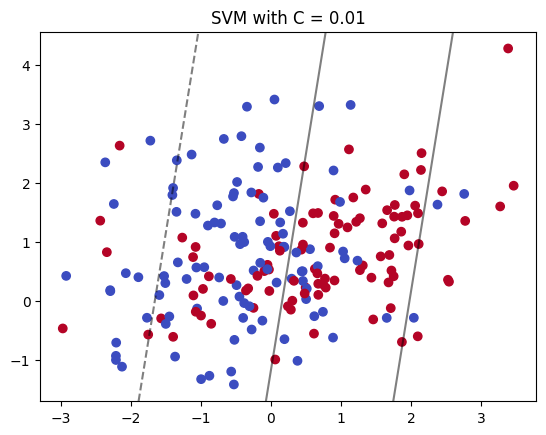

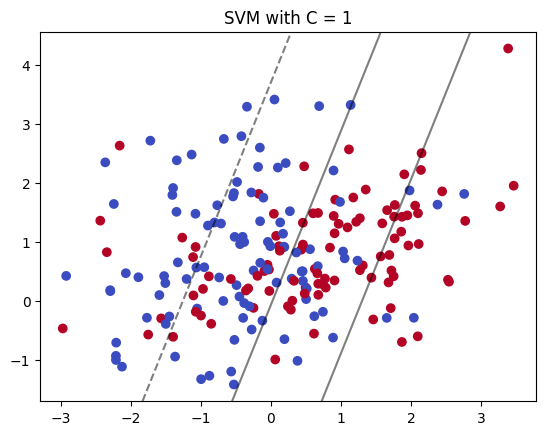

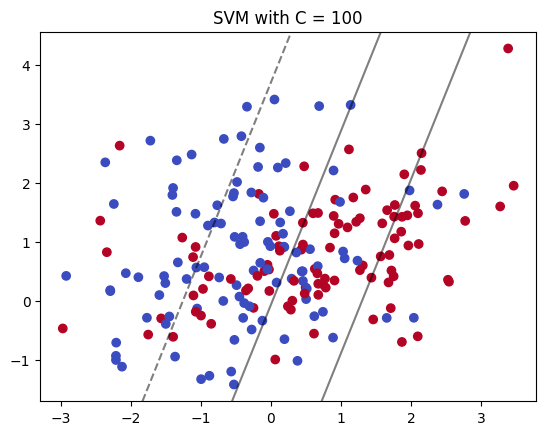

In [8]:
for model, C in zip(models, C_values):
    plot_svm(model, f"SVM with C = {C}")


In [10]:
for model, C in zip(models, C_values):
    pred = model.predict(X)
    errors = np.sum(pred != y)
    print(f"C={C}, Misclassified Points:", errors)


C=0.01, Misclassified Points: 56
C=1, Misclassified Points: 56
C=100, Misclassified Points: 56


## The parameter C in SVM controls how strictly the model tries to avoid classification errors. When C is small, the model allows more misclassified points in order to maintain a wider margin, which can improve generalization. As C increases, the model penalizes errors more strongly, resulting in a narrower margin and fewer training errors. However, very large C values may cause the model to overfit noisy data.